# Phase 0 - Documented Baseline
### Lung cancer detection on IQ-OTH/NCCD: U-Net segmentation + ViT classification

**Purpose.** Lock down an honest, reproducible "before" number for the paper, and
diagnose *why* the current pipeline scores ~0.39 accuracy.

**Run on:** Google Colab, free T4 GPU (`Runtime > Change runtime type > T4 GPU`).
Expected wall time: ~15-25 min.

---

### What this notebook measures

| Stage | Question it answers |
|---|---|
| 3.2 Leakage | 1097 images come from only **110 cases**. How much does an image-level split leak? |
| A. Segmentation | What does the U-Net actually output? (no ground-truth masks exist - see note) |
| B. Whole-image ViT | How good is the classifier **on the distribution it was trained on**? |
| B2. Channel order | Does RGB-vs-BGR at inference matter? |
| C. Full pipeline | The deployed system, end-to-end, on all 1097 images |
| C2. Decision rules | How much of the malignant bias comes from "any malignant patch -> malignant"? |
| D. Reproduction | Does the original 90-image protocol still give ~0.389? (sanity check) |

### Three problems in the original code that this notebook quantifies

1. **Train/inference distribution mismatch.** The ViT was trained on *whole* CT
   images resized to 30x30 (`Image.open(f).resize((30,30))`, final array
   `(1097, 30, 30, 3)`). At inference it is fed 30x30 *crops* cut out of a
   512x512 image. A downsampled whole lung and a 30x30 crop are different
   distributions; the classifier was never trained on the latter. Stage B vs
   Stage C isolates this.
2. **Channel order.** Training loaded images with PIL (RGB). The inference
   notebook uses `cv2.imread` (BGR) and never converts. Stage B2 measures it.
3. **Evaluation leakage, twice over.** The reported 0.389 comes from 90 images
   sampled at random from the *whole* dataset, overlapping the ViT's training split.
   Worse, the dataset is 1097 images from only **110 cases**, so even a "proper"
   image-level split leaks slices of one patient across train and test. Section 3.2
   measures this and builds a grouped split that does not.

### Note on Dice / IoU - read before writing the paper

IQ-OTH/NCCD provides **class labels only**. There are no per-pixel nodule
annotations in the dataset, and no ground-truth masks were shipped with the FYP.
Dice and IoU against ground truth are therefore **not computable here**, and the
paper must not report them for this dataset. Stage A instead characterises the
segmentation output descriptively.

Quantitative segmentation numbers come from **Phase 2S** instead: the U-Net is
retrained and scored on Medical Segmentation Decathlon Task06_Lung, which has real
voxel-level expert masks. See `FYP_PLAN_V2.md`. Segmentation output on
IQ-OTH/NCCD stays qualitative, and the paper says so explicitly.

## 1. Environment

In [22]:
import subprocess, sys
for pkg in ["kagglehub", "scikit-image", "seaborn", "opencv-python-headless", "tabulate"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import tensorflow as tf, keras
print("tensorflow:", tf.__version__)
print("keras     :", keras.__version__)
print("GPUs      :", tf.config.list_physical_devices("GPU"))

tensorflow: 2.20.0
keras     : 3.13.2
GPUs      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [23]:
import os, json, random, glob, shutil, math
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage import measure
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                             accuracy_score, balanced_accuracy_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

CLASS_NAMES = ["Benign", "Malignant", "Normal"]   # 0, 1, 2  (as in training)
FOLDERS = {"Benign": "Bengin cases",              # sic - dataset folder is misspelled
           "Malignant": "Malignant cases",
           "Normal": "Normal cases"}
LABEL_TO_IDX = {"Benign": 0, "Malignant": 1, "Normal": 2}

RESULTS_DIR = "/content/fyp_phase0_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS = {"seed": SEED}

def save_json():
    with open(f"{RESULTS_DIR}/results.json", "w") as f:
        json.dump(RESULTS, f, indent=2, default=float)

print("results ->", RESULTS_DIR)

results -> /content/fyp_phase0_results


## 2. Trained weights

Two files are needed:

- `UNet_best_Model_checkpoint.h5` (~31 MB)
- `vit_classifier.weights.h5` (~266 MB)

Both are inside `fyp.rar` locally. Pick **one** source below by setting
`WEIGHTS_SOURCE`:

- `"url"` - **preferred.** Direct download, no credentials, fastest. Point
  `WEIGHTS_URLS` at a GitHub release (or any public direct link).
- `"drive"` - upload both files to a Google Drive folder first.
- `"hf"` - pull from a Hugging Face model repo. Set `HF_REPO`; paste the token into
  the prompt when asked (private repos only). **Never hard-code the token here.**
- `"upload"` - upload through the browser each session (slow for the 266 MB file).

In [24]:
WEIGHTS_SOURCE = "url"            # "url" | "drive" | "hf" | "upload"

_REL = "https://github.com/haseebkhan9081/LViT_Vision_Transformer/releases/download/weights-v1"
WEIGHTS_URLS = {"UNet_best_Model_checkpoint.h5": f"{_REL}/UNet_best_Model_checkpoint.h5",
                "vit_classifier.weights.h5":     f"{_REL}/vit_classifier.weights.h5"}
DRIVE_WEIGHTS_DIR = "/content/drive/MyDrive/FYP/weights"
HF_REPO = "haseebkhan1234567/fyp-lvit-weights"   # only used when WEIGHTS_SOURCE == "hf"

WEIGHTS_DIR = "/content/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
UNET_PATH = f"{WEIGHTS_DIR}/UNet_best_Model_checkpoint.h5"
VIT_PATH  = f"{WEIGHTS_DIR}/vit_classifier.weights.h5"

if WEIGHTS_SOURCE == "url":
    for name, url in WEIGHTS_URLS.items():
        dest = os.path.join(WEIGHTS_DIR, name)
        subprocess.run(["wget", "-q", "--show-progress", "-O", dest, url], check=True)

elif WEIGHTS_SOURCE == "drive":
    from google.colab import drive
    drive.mount("/content/drive")
    for name in ["UNet_best_Model_checkpoint.h5", "vit_classifier.weights.h5"]:
        src = os.path.join(DRIVE_WEIGHTS_DIR, name)
        assert os.path.exists(src), f"missing in Drive: {src}"
        shutil.copy(src, os.path.join(WEIGHTS_DIR, name))

elif WEIGHTS_SOURCE == "hf":
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"], check=False)
    from huggingface_hub import hf_hub_download
    from getpass import getpass
    tok = getpass("HF token (input hidden, kept in memory only): ").strip()
    for name, dest in [("UNet_best_Model_checkpoint.h5", UNET_PATH),
                       ("vit_classifier.weights.h5", VIT_PATH)]:
        p = hf_hub_download(repo_id=HF_REPO, filename=name, token=tok)
        shutil.copy(p, dest)
    del tok

elif WEIGHTS_SOURCE == "upload":
    from google.colab import files
    up = files.upload()
    for name in up:
        shutil.move(name, os.path.join(WEIGHTS_DIR, name))

# Size check: a 404 or an HTML error page would otherwise fail much later with a
# confusing Keras error. Expected 31.2 MB and 266.7 MB.
for p, mb in [(UNET_PATH, 31.2), (VIT_PATH, 266.7)]:
    got = os.path.getsize(p) / 1e6
    print(f"{os.path.basename(p):35s} {got:8.1f} MB  (expected ~{mb} MB)")
    assert abs(got - mb) < 1.0, f"{p} is the wrong size - bad download?"
print("weights OK")

UNet_best_Model_checkpoint.h5           31.2 MB  (expected ~31.2 MB)
vit_classifier.weights.h5              266.7 MB  (expected ~266.7 MB)
weights OK


## 3. Dataset

**Kaggle credentials.** Add **`KAGGLE_API_TOKEN`** to Colab Secrets (key icon in the
left sidebar), set to the `KGAT_...` token from
[kaggle.com/settings](https://www.kaggle.com/settings) -> API Tokens, and switch on
notebook access for it. The legacy `KAGGLE_USERNAME` + `KAGGLE_KEY` pair still works as
a fallback.

Never paste the token into a notebook cell, a chat, or any file. Colab Secrets exist so
it stays out of the notebook, and a token that has been pasted anywhere should be
expired and regenerated from that same settings page.

In [25]:
# Kaggle needs credentials even for public datasets.
#
# PREFERRED: add KAGGLE_API_TOKEN to Colab Secrets (key icon, left sidebar) with
# notebook access enabled. That is the new-style "KGAT_..." token from
# kaggle.com/settings -> API Tokens. It needs kagglehub >= 0.4.1, hence the upgrade.
# Fallbacks: legacy KAGGLE_USERNAME + KAGGLE_KEY, then a kaggle.json upload.
#
# The token is read straight from Secrets into the environment. It is never written
# to disk here and must never be pasted into this notebook.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "kagglehub"],
               check=False)

def _secret(name):
    try:
        from google.colab import userdata
        v = userdata.get(name)
        return v.strip() if v else None
    except Exception:
        return None

if _secret("KAGGLE_API_TOKEN"):
    os.environ["KAGGLE_API_TOKEN"] = _secret("KAGGLE_API_TOKEN")
    print("Kaggle auth: KAGGLE_API_TOKEN from Colab Secrets")
elif _secret("KAGGLE_USERNAME") and _secret("KAGGLE_KEY"):
    os.environ["KAGGLE_USERNAME"] = _secret("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = _secret("KAGGLE_KEY")
    print("Kaggle auth: legacy KAGGLE_USERNAME/KAGGLE_KEY from Colab Secrets")
else:
    print("No Kaggle secret found. Upload kaggle.json instead.")
    from google.colab import files
    files.upload()
    os.makedirs("/root/.config/kaggle", exist_ok=True)
    shutil.copy("kaggle.json", "/root/.config/kaggle/kaggle.json")
    os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

import kagglehub
print("kagglehub:", kagglehub.__version__)
DL = kagglehub.dataset_download("hamdallak/the-iqothnccd-lung-cancer-dataset")
DATA_ROOT = os.path.join(DL, "The IQ-OTHNCCD lung cancer dataset")
if not os.path.isdir(DATA_ROOT):          # layout varies between versions
    cands = [d for d, _, _ in os.walk(DL) if os.path.basename(d) == "Malignant cases"]
    assert cands, f"could not locate class folders under {DL}"
    DATA_ROOT = os.path.dirname(cands[0])
print("DATA_ROOT:", DATA_ROOT)
print(sorted(os.listdir(DATA_ROOT)))

Kaggle auth: KAGGLE_API_TOKEN from Colab Secrets
kagglehub: 1.0.2
Using Colab cache for faster access to the 'the-iqothnccd-lung-cancer-dataset' dataset.
DATA_ROOT: /kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset
['Bengin cases', 'IQ-OTH_NCCD lung cancer dataset.txt', 'Malignant cases', 'Normal cases']


In [26]:
rows = []
for cls, folder in FOLDERS.items():
    d = os.path.join(DATA_ROOT, folder)
    for fn in sorted(os.listdir(d)):
        if fn.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append({"path": os.path.join(d, fn), "file": fn,
                         "label": cls, "y": LABEL_TO_IDX[cls]})
df = pd.DataFrame(rows).sort_values("path").reset_index(drop=True)

print("total images:", len(df))
print(df["label"].value_counts().to_string())
RESULTS["dataset"] = {"n_total": int(len(df)),
                      "per_class": df["label"].value_counts().to_dict()}
save_json()
df.head()

total images: 1097
label
Malignant    561
Normal       416
Benign       120


,path,file,label,y
0,/kaggle/input/the-iqothnccd-lung-cancer-datase...,Bengin case (1).jpg,Benign,0
1,/kaggle/input/the-iqothnccd-lung-cancer-datase...,Bengin case (10).jpg,Benign,0
2,/kaggle/input/the-iqothnccd-lung-cancer-datase...,Bengin case (100).jpg,Benign,0
3,/kaggle/input/the-iqothnccd-lung-cancer-datase...,Bengin case (101).jpg,Benign,0
4,/kaggle/input/the-iqothnccd-lung-cancer-datase...,Bengin case (102).jpg,Benign,0


### 3.1 A fixed split we can actually defend

The original ViT was trained with `train_test_split(test_size=0.2, random_state=0)`
over a **Google Drive copy** of the dataset whose file ordering we cannot recover.
So the exact training split is unrecoverable, and **every evaluation of these
weights is contaminated to some unknown degree**. That is a fact about the
existing weights, not something this notebook can fix - it gets stated plainly in
the paper, and Phase 2 retrains from scratch on the split defined here.

The split below (70/15/15 stratified, seed 42) is written to CSV. **It is not the
final protocol** - see 3.2, which is the one that matters.

In [27]:
tr, tmp = train_test_split(df, test_size=0.30, stratify=df["y"], random_state=SEED)
va, te  = train_test_split(tmp, test_size=0.50, stratify=tmp["y"], random_state=SEED)
df["split"] = "train"
df.loc[va.index, "split"] = "val"
df.loc[te.index, "split"] = "test"

split_csv = f"{RESULTS_DIR}/split_seed{SEED}.csv"
df[["file", "label", "y", "split"]].to_csv(split_csv, index=False)

print(pd.crosstab(df["split"], df["label"]).to_string())
RESULTS["split"] = {"scheme": "stratified 70/15/15 BY IMAGE (leaky - see 3.2)",
                    "seed": SEED,
                    "counts": pd.crosstab(df["split"], df["label"]).to_dict()}
save_json()

label  Benign  Malignant  Normal
split                           
test       18         85      62
train      84        392     291
val        18         84      63


### 3.2 The split above is leaky, and so is most of the published literature

IQ-OTH/NCCD is **1097 images from 110 cases**. Each scan contributes roughly ten
slices. Splitting by *image* therefore puts slices of the **same patient** in both
train and test, and adjacent CT slices of one patient are near-duplicates. A model can
score well by recognising the patient rather than the pathology.

This is not a hypothetical. Published work on this dataset reports 98-100% accuracy,
and at least one author documented finding **43 duplicate images across their train and
validation sets**, with accuracy dropping from a suspicious 100% to 95.7% once removed.
Patient-level partitioning is now recognised as the correct protocol here.

**The dataset ships no patient IDs**, so a true patient-level split cannot be
constructed directly. What we can do is recover the grouping empirically: slices from
one scan are highly correlated, so we build a similarity graph over all 1097 images and
take its connected components as **pseudo-patient groups**.

There is a strong falsifiable check available. If the recovered component count lands
near **110**, the known number of cases, then the grouping has plausibly recovered the
real case structure. If it does not, we say so and treat the grouping as approximate.
Either way the sweep below is reported rather than tuned silently.

In [28]:
# 64x64 grayscale, per-image standardised, cosine similarity. Cheap on 1097 images.
thumbs = []
for p in tqdm(df["path"], desc="thumbnails"):
    g = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2GRAY)
    g = cv2.resize(g, (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32).ravel()
    g -= g.mean()
    n = np.linalg.norm(g)
    thumbs.append(g / n if n > 0 else g)
T = np.stack(thumbs)
S = T @ T.T                       # cosine similarity, 1097 x 1097
np.fill_diagonal(S, 0.0)
print("similarity matrix:", S.shape)

def components(thresh):
    # union-find over edges above `thresh`
    parent = list(range(len(S)))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    ii, jj = np.where(np.triu(S, 1) >= thresh)
    for a, b in zip(ii, jj):
        ra, rb = find(int(a)), find(int(b))
        if ra != rb: parent[ra] = rb
    roots = [find(i) for i in range(len(S))]
    remap = {r: k for k, r in enumerate(sorted(set(roots)))}
    return np.array([remap[r] for r in roots])

sweep = {}
for t in [0.90, 0.925, 0.95, 0.96, 0.97, 0.98, 0.99]:
    sweep[t] = int(components(t).max() + 1)
    print(f"similarity >= {t:.3f} -> {sweep[t]:4d} groups")

KNOWN_CASES = 110
BEST_T = min(sweep, key=lambda t: abs(sweep[t] - KNOWN_CASES))
groups = components(BEST_T)
n_groups = int(groups.max() + 1)
print(f"\nclosest to the known {KNOWN_CASES} cases: threshold {BEST_T} -> {n_groups} groups")
print("group size: mean %.1f, max %d, singletons %d" % (
    np.bincount(groups).mean(), np.bincount(groups).max(), int((np.bincount(groups) == 1).sum())))

df["group"] = groups
RESULTS["pseudo_patient_grouping"] = {
    "threshold_sweep": {str(k): v for k, v in sweep.items()},
    "known_cases": KNOWN_CASES, "selected_threshold": BEST_T, "n_groups": n_groups,
    "recovered_near_known": bool(abs(n_groups - KNOWN_CASES) <= 25),
}
save_json()

thumbnails:   0%|          | 0/1097 [00:00<?, ?it/s]

similarity matrix: (1097, 1097)
similarity >= 0.900 ->  117 groups
similarity >= 0.925 ->  136 groups
similarity >= 0.950 ->  179 groups
similarity >= 0.960 ->  209 groups
similarity >= 0.970 ->  258 groups
similarity >= 0.980 ->  347 groups
similarity >= 0.990 ->  558 groups

closest to the known 110 cases: threshold 0.9 -> 117 groups
group size: mean 9.4, max 54, singletons 11


Exact and near-duplicate pairs, counted separately. These are the images that make an
image-level split indefensible, and the count is a citable number for the paper.

In [29]:
iu = np.triu_indices(len(S), 1)
sims = S[iu]
for t in [0.99, 0.98, 0.95]:
    n_pairs = int((sims >= t).sum())
    imgs = len(set(np.concatenate([iu[0][sims >= t], iu[1][sims >= t]])))
    print(f"pairs with similarity >= {t:.2f}: {n_pairs:6d}  (involving {imgs} of {len(df)} images)")

cross = 0
for t in [0.98]:
    a, b = iu[0][sims >= t], iu[1][sims >= t]
    cross = int((df["split"].to_numpy()[a] != df["split"].to_numpy()[b]).sum())
print(f"\nnear-duplicate pairs (>=0.98) SPLIT ACROSS the image-level split: {cross}")
print("Each one is a train/test leak in the naive protocol.")
RESULTS["duplicate_analysis"] = {
    "pairs_ge_0.99": int((sims >= 0.99).sum()),
    "pairs_ge_0.98": int((sims >= 0.98).sum()),
    "pairs_ge_0.95": int((sims >= 0.95).sum()),
    "near_dup_pairs_crossing_image_level_split": cross}
save_json()

pairs with similarity >= 0.99:    960  (involving 692 of 1097 images)
pairs with similarity >= 0.98:   1664  (involving 914 of 1097 images)
pairs with similarity >= 0.95:   3192  (involving 1051 of 1097 images)

near-duplicate pairs (>=0.98) SPLIT ACROSS the image-level split: 773
Each one is a train/test leak in the naive protocol.


### 3.3 The grouped split - this is the protocol everything else uses

Groups are assigned whole to train/val/test, so no pseudo-patient appears in two
splits. Class balance is approximate rather than exact, because a group cannot be
divided.

In [30]:
from sklearn.model_selection import GroupShuffleSplit

gdf = df.groupby("group").agg(y=("y", lambda s: s.mode().iloc[0]), n=("y", "size")).reset_index()
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
tr_g, tmp_g = next(gss1.split(gdf, gdf["y"], groups=gdf["group"]))
tmp = gdf.iloc[tmp_g]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
va_g, te_g = next(gss2.split(tmp, tmp["y"], groups=tmp["group"]))

assign = {}
for g in gdf.iloc[tr_g]["group"]:        assign[g] = "train"
for g in tmp.iloc[va_g]["group"]:        assign[g] = "val"
for g in tmp.iloc[te_g]["group"]:        assign[g] = "test"
df["split_grouped"] = df["group"].map(assign)

print(pd.crosstab(df["split_grouped"], df["label"]).to_string())
print("\ngroups per split:", df.groupby("split_grouped")["group"].nunique().to_dict())
overlap = df.groupby("group")["split_grouped"].nunique().max()
assert overlap == 1, "a group landed in more than one split"
print("verified: no group spans two splits")

df[["file", "label", "y", "group", "split", "split_grouped"]].to_csv(split_csv, index=False)
RESULTS["split_grouped"] = {
    "scheme": "GroupShuffleSplit 70/15/15 over pseudo-patient groups",
    "counts": pd.crosstab(df["split_grouped"], df["label"]).to_dict(),
    "groups_per_split": df.groupby("split_grouped")["group"].nunique().to_dict()}
save_json()

label          Benign  Malignant  Normal
split_grouped                           
test               23         61      48
train              84        401     310
val                13         99      58

groups per split: {'test': 18, 'train': 81, 'val': 18}
verified: no group spans two splits


## 4. Load the trained models

In [31]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true); y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

unet_model = tf.keras.models.load_model(
    UNET_PATH, custom_objects={"dice_coef": dice_coef, "dice_coef_loss": dice_coef_loss},
    compile=False)
print("U-Net in :", unet_model.input_shape)
print("U-Net out:", unet_model.output_shape)
print("params   :", f"{unet_model.count_params():,}")

U-Net in : (None, 512, 512, 1)
U-Net out: (None, 512, 512, 1)
params   : 7,759,521


In [32]:
# ViT architecture - kept byte-identical to the training notebook so the saved
# weights load by structure. Do NOT call adapt() on the Normalization layer:
# its mean/variance are non-trainable weights restored from the checkpoint.
image_size, patch_size = 72, 6
num_patches = (image_size // patch_size) ** 2      # 144
projection_dim, num_heads, transformer_layers = 64, 8, 8
transformer_units = [projection_dim * 2, projection_dim]
mlp_head_units = [2048, 1024]
n_classes = 3

class Patches(layers.Layer):
    def __init__(self, patch_size, **kw):
        super().__init__(**kw); self.patch_size = patch_size
    def call(self, images):
        b = tf.shape(images)[0]
        p = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1], padding="VALID")
        dims = self.patch_size * self.patch_size * images.shape[-1]
        return tf.reshape(p, [b, -1, dims])

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kw):
        super().__init__(**kw)
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches,
                                                   output_dim=projection_dim)
    def call(self, patch):
        pos = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(pos)

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def create_vit_classifier():
    inputs = layers.Input(shape=(30, 30, 3))
    data_augmentation = keras.Sequential([
        layers.Normalization(),
        layers.Resizing(72, 72),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ], name="data_augmentation")
    x = data_augmentation(inputs)
    x = Patches(patch_size)(x)
    encoded = PatchEncoder(num_patches, projection_dim)(x)
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        att = layers.MultiHeadAttention(num_heads=num_heads,
                                        key_dim=projection_dim, dropout=0.1)(x1, x1)
        x2 = layers.Add()([att, encoded])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded = layers.Add()([x3, x2])
    rep = layers.LayerNormalization(epsilon=1e-6)(encoded)
    rep = layers.Flatten()(rep)
    rep = layers.Dropout(0.5)(rep)
    feats = mlp(rep, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = layers.Dense(n_classes)(feats)
    return keras.Model(inputs=inputs, outputs=logits)

vit_model = create_vit_classifier()
vit_model.load_weights(VIT_PATH)
print("ViT params:", f"{vit_model.count_params():,}")

ViT params: 22,190,026


**Sanity check on the normalization statistics.** The `Normalization` layer was
`adapt()`-ed on the training data. If its mean/variance came back as the
uninitialised 0/1 defaults, the checkpoint did not restore them and *every*
number below would be wrong. Check before trusting anything.

In [33]:
norm = vit_model.get_layer("data_augmentation").layers[0]
mean, var = np.array(norm.mean).ravel(), np.array(norm.variance).ravel()
print("Normalization mean:", np.round(mean, 3))
print("Normalization var :", np.round(var, 3))
restored = not (np.allclose(mean, 0) and np.allclose(var, 1))
print("\nadapted stats restored from checkpoint:", restored)
if not restored:
    print("WARNING: stats are at defaults (0/1). Inputs are effectively unnormalised;\n"
          "         treat all downstream metrics as suspect and report this.")
RESULTS["vit_norm_stats"] = {"mean": mean.tolist(), "var": var.tolist(),
                             "restored": bool(restored)}
save_json()

Normalization mean: [104.6 104.6 104.6]
Normalization var : [5121.837 5121.837 5121.837]

adapted stats restored from checkpoint: True


## 5. Shared helpers (preprocessing + metrics)

In [34]:
def preprocess_for_unet(img_bgr):
    # Identical to unet_lvit.ipynb: gray -> 512 -> CLAHE -> crude lung ROI -> [-1,1]
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim > 2 else img_bgr
    g = cv2.resize(g, (512, 512))
    g = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(g.astype(np.uint8))
    _, roi = cv2.threshold(g, 127, 255, cv2.THRESH_BINARY_INV)
    roi = cv2.erode(roi, kernel=np.ones([4, 4]))
    roi = cv2.dilate(roi, kernel=np.ones([13, 13]))
    lungs = cv2.bitwise_and(g, g, mask=roi)
    return ((lungs - 127.0) / 127.0).astype(np.float32)

def evaluate(y_true, y_pred, title, note=""):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
    out = {
        "title": title, "note": note, "n": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(p.mean()), "macro_recall": float(r.mean()),
        "macro_f1": float(f1.mean()),
        "per_class": {c: {"precision": float(p[i]), "recall": float(r[i]),
                          "f1": float(f1[i]), "support": int(sup[i])}
                      for i, c in enumerate(CLASS_NAMES)},
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1, 2]).tolist(),
        "pred_distribution": {c: int((y_pred == i).sum()) for i, c in enumerate(CLASS_NAMES)},
    }
    print(f"\n=== {title}  (n={out['n']}) ===")
    if note: print(note)
    print(f"{'class':<11}{'prec':>8}{'rec':>8}{'f1':>8}{'n':>7}")
    for c in CLASS_NAMES:
        m = out["per_class"][c]
        print(f"{c:<11}{m['precision']:>8.3f}{m['recall']:>8.3f}{m['f1']:>8.3f}{m['support']:>7d}")
    print(f"accuracy {out['accuracy']:.3f} | balanced-acc {out['balanced_accuracy']:.3f} "
          f"| macro-F1 {out['macro_f1']:.3f}")
    print("predicted:", out["pred_distribution"])
    return out

def plot_cm(res, fname):
    cm = np.array(res["confusion_matrix"])
    plt.figure(figsize=(5.2, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    plt.title(res["title"], fontsize=10)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{fname}", dpi=150); plt.close()

## Stage A - What does the U-Net actually segment?

No ground-truth masks exist for this dataset, so this is descriptive, not a score.
What we can report honestly: predicted foreground area, how many disconnected
regions the mask breaks into, and how many images get an empty mask. Those three
numbers drive the patch-extraction stage, so they matter for the failure analysis
even without Dice.

In [35]:
BATCH = 16
mask_stats, mask_cache = [], {}
demo_idx = df.groupby("label").head(2).index.tolist()          # 2 per class for the figure

for start in tqdm(range(0, len(df), BATCH), desc="U-Net"):
    chunk = df.iloc[start:start + BATCH]
    pre = np.stack([preprocess_for_unet(cv2.imread(p)) for p in chunk["path"]])
    pr = unet_model.predict(pre[..., None], verbose=0)
    binm = (np.squeeze(pr, -1) >= 0.5).astype(np.uint8) * 255
    for (i, row), m in zip(chunk.iterrows(), binm):
        n_reg = measure.label(m).max()
        mask_stats.append({"idx": i, "label": row["label"],
                           "area_frac": float((m > 0).mean()),
                           "n_regions": int(n_reg),
                           "empty": bool(n_reg == 0)})
        if i in demo_idx:
            mask_cache[i] = (pre[list(chunk.index).index(i)].copy(), m.copy())

ms = pd.DataFrame(mask_stats)
summary = ms.groupby("label").agg(
    mean_area_frac=("area_frac", "mean"),
    median_area_frac=("area_frac", "median"),
    mean_regions=("n_regions", "mean"),
    empty_masks=("empty", "sum")).round(4)
print(summary.to_string())
print(f"\nimages with an empty mask: {int(ms['empty'].sum())} / {len(ms)}")

RESULTS["stage_A_segmentation"] = {
    "note": ("IQ-OTH/NCCD has no per-pixel ground truth; Dice/IoU are not computable. "
             "Descriptive statistics of the predicted masks only."),
    "per_class": summary.to_dict(),
    "n_empty_masks": int(ms["empty"].sum()),
    "overall_mean_area_frac": float(ms["area_frac"].mean()),
    "overall_mean_regions": float(ms["n_regions"].mean()),
}
save_json()

U-Net:   0%|          | 0/69 [00:00<?, ?it/s]

           mean_area_frac  median_area_frac  mean_regions  empty_masks
label                                                                 
Benign             0.0027            0.0027       13.4500            8
Malignant          0.0032            0.0030       17.4207            0
Normal             0.0023            0.0022       13.0312           23

images with an empty mask: 31 / 1097


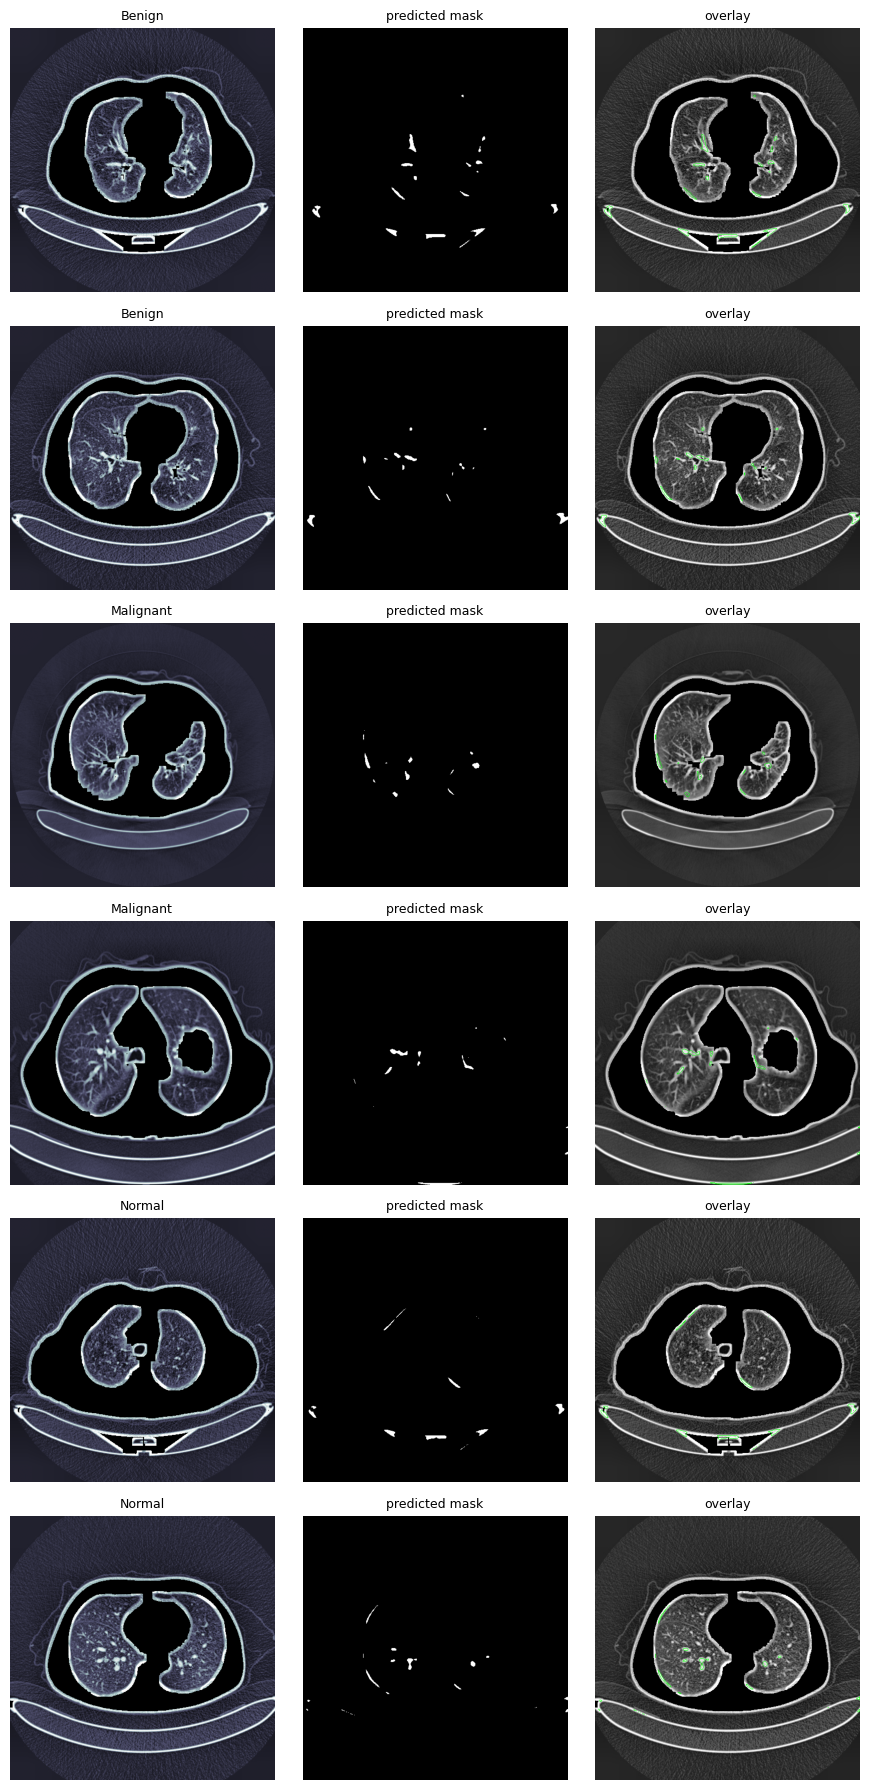

saved fig_segmentation_examples.png


In [36]:
fig, axes = plt.subplots(len(mask_cache), 3, figsize=(9, 3 * len(mask_cache)))
for ax_row, (i, (pre, m)) in zip(np.atleast_2d(axes), mask_cache.items()):
    disp = ((pre - pre.min()) / (pre.max() - pre.min() + 1e-6) * 255).astype(np.uint8)
    ax_row[0].imshow(disp, cmap="bone"); ax_row[0].set_title(df.loc[i, "label"], fontsize=9)
    ax_row[1].imshow(m, cmap="gray");    ax_row[1].set_title("predicted mask", fontsize=9)
    ov = cv2.cvtColor(disp, cv2.COLOR_GRAY2RGB)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(ov, cnts, -1, (0, 255, 0), 1)
    ax_row[2].imshow(ov);                ax_row[2].set_title("overlay", fontsize=9)
    for a in ax_row: a.axis("off")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/fig_segmentation_examples.png", dpi=150)
plt.show()
print("saved fig_segmentation_examples.png")

## Stage B - The ViT on its own training distribution

Feed whole images resized to 30x30 with PIL, exactly as in
`LViT_Vision_Transformer.ipynb`. This is the classifier's *best case*: matched
distribution, no segmentation, no patching, no voting.

Reported on all 1097 images (leakage-contaminated, comparable to the original
report) **and** on the held-out test split of our fixed protocol. The gap between
those two numbers is a direct measure of how much memorisation is inflating the
original figure.

In [37]:
def load_whole_images(paths, bgr=False):
    out = []
    for p in paths:
        im = Image.open(p).convert("RGB").resize((30, 30))
        a = np.array(im, dtype=np.float32)              # RGB, [0,255]
        if bgr: a = a[..., ::-1]
        out.append(a)
    return np.stack(out)

X_all_rgb = load_whole_images(df["path"].tolist())
y_all = df["y"].to_numpy()
logits_all = vit_model.predict(X_all_rgb, batch_size=256, verbose=1)
pred_all = logits_all.argmax(1)

res_b_all = evaluate(y_all, pred_all, "B. Whole-image ViT (RGB) - all 1097",
                     note="Overlaps the ViT's training data; NOT a clean number.")
plot_cm(res_b_all, "cm_B_wholeimage_all.png")

te_mask = (df["split"] == "test").to_numpy()
res_b_te = evaluate(y_all[te_mask], pred_all[te_mask],
                    "B. Whole-image ViT (RGB) - image-level test split",
                    note="Leaky by construction (slices of one patient span splits).")
plot_cm(res_b_te, "cm_B_wholeimage_test.png")

tg_mask = (df["split_grouped"] == "test").to_numpy()
res_b_tg = evaluate(y_all[tg_mask], pred_all[tg_mask],
                    "B. Whole-image ViT (RGB) - GROUPED test split",
                    note="No pseudo-patient spans splits. Still contaminated by the "
                         "ViT's own unrecoverable training split, but free of the "
                         "image-level leak. The image-level minus grouped gap is the "
                         "size of that leak.")
plot_cm(res_b_tg, "cm_B_wholeimage_test_grouped.png")
print(f"\nleak size (image-level acc - grouped acc): "
      f"{res_b_te['accuracy'] - res_b_tg['accuracy']:+.3f}")

RESULTS["stage_B_whole_image"] = {"all": res_b_all, "test_split": res_b_te,
                                  "test_split_grouped": res_b_tg,
                                  "image_level_leak_delta": res_b_te["accuracy"] - res_b_tg["accuracy"]}
save_json()

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 535ms/step

=== B. Whole-image ViT (RGB) - all 1097  (n=1097) ===
Overlaps the ViT's training data; NOT a clean number.
class          prec     rec      f1      n
Benign        0.833   0.417   0.556    120
Malignant     0.978   0.955   0.967    561
Normal        0.826   0.971   0.893    416
accuracy 0.902 | balanced-acc 0.781 | macro-F1 0.805
predicted: {'Benign': 60, 'Malignant': 548, 'Normal': 489}

=== B. Whole-image ViT (RGB) - image-level test split  (n=165) ===
Leaky by construction (slices of one patient span splits).
class          prec     rec      f1      n
Benign        0.909   0.556   0.690     18
Malignant     1.000   0.953   0.976     85
Normal        0.836   0.984   0.904     62
accuracy 0.921 | balanced-acc 0.831 | macro-F1 0.856
predicted: {'Benign': 11, 'Malignant': 81, 'Normal': 73}

=== B. Whole-image ViT (RGB) - GROUPED test split  (n=132) ===
No pseudo-patient spans splits. Still contaminated by the ViT's own unrecoverable training spli

### B2 - Channel order

The deployed pipeline feeds `cv2.imread` output (BGR) to a model trained on PIL
output (RGB). If the two rows below differ materially, that is a real bug in the
deployed system and belongs in the paper's failure analysis. If they barely
differ, say so - these CT slices are near-grayscale, so a small gap is the
expected result and is worth reporting as a ruled-out hypothesis.

In [38]:
X_all_bgr = X_all_rgb[..., ::-1]
pred_bgr = vit_model.predict(X_all_bgr, batch_size=256, verbose=0).argmax(1)
res_b2 = evaluate(y_all, pred_bgr, "B2. Whole-image ViT (BGR) - all 1097",
                  note="Same images, channels reversed, to isolate the cv2/PIL mismatch.")
delta = res_b2["accuracy"] - res_b_all["accuracy"]
disagree = float((pred_bgr != pred_all).mean())
print(f"\naccuracy delta (BGR - RGB): {delta:+.3f}")
print(f"predictions that change     : {disagree:.1%}")
RESULTS["stage_B2_channel_order"] = {"bgr": res_b2, "accuracy_delta": delta,
                                     "prediction_disagreement": disagree}
save_json()


=== B2. Whole-image ViT (BGR) - all 1097  (n=1097) ===
Same images, channels reversed, to isolate the cv2/PIL mismatch.
class          prec     rec      f1      n
Benign        0.833   0.417   0.556    120
Malignant     0.978   0.955   0.967    561
Normal        0.826   0.971   0.893    416
accuracy 0.902 | balanced-acc 0.781 | macro-F1 0.805
predicted: {'Benign': 60, 'Malignant': 548, 'Normal': 489}

accuracy delta (BGR - RGB): +0.000
predictions that change     : 0.0%


## Stage C - The full deployed pipeline

Faithful re-implementation of `unet_lvit.ipynb` cell 14: segment, dilate, take
region bounding boxes, pad by 10 px, crop (re-centring boxes smaller than 30 px),
add an equal number of random non-nodule patches, classify every patch, then vote.

Two changes, both for correctness rather than performance:

- Patches are classified in **batches** instead of one `predict()` call per patch,
  which is what limited the original run to 90 images. Same maths, ~100x faster.
- Every patch is tagged as nodule-derived or random, so the decision rules below
  can be compared on identical predictions.

Test-time augmentation is **off by default**: the original used
`ImageDataGenerator`, which no longer exists in Keras 3, so any TTA here is a
reimplementation rather than a reproduction. A seeded reimplementation is
available via `USE_TTA = True`, and it is reported separately if enabled.

In [39]:
USE_TTA = False        # True -> 5x seeded affine TTA (reimplementation, not the original)
TTA_N = 5

def extract_patches_for_image(img_bgr_512, mask, rng):
    # Returns (patches [N,30,30,3] float32 BGR, is_nodule [N] bool)
    m = cv2.dilate(mask, kernel=np.ones((5, 5)))
    regions = measure.regionprops(measure.label(m))
    boxes = [((max(0, b[1] - 10), max(0, b[0] - 10)),
              (min(b[3] + 10, 512), min(b[2] + 10, 512)))
             for b in (r.bbox for r in regions)]

    patches, is_nodule = [], []
    for (x1, y1), (x2, y2) in boxes:
        if abs(x1 - x2) <= 30 or abs(y1 - y2) <= 30:      # re-centre tiny boxes to 30x30
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            x1, x2 = max(cx - 15, 0), min(cx + 15, 512)
            y1, y2 = max(cy - 15, 0), min(cy + 15, 512)
        crop = img_bgr_512[y1:y2, x1:x2]
        if crop.size and crop.shape[0] > 0 and crop.shape[1] > 0:
            patches.append(cv2.resize(crop, (30, 30)) if crop.shape[:2] != (30, 30) else crop)
            is_nodule.append(True)

    for _ in range(max(1, len(patches))):                  # random non-nodule patches
        for _ in range(10):
            x1 = rng.randint(30, 482); y1 = rng.randint(30, 482)
            pm = mask[y1:y1 + 30, x1:x1 + 30]
            if pm.shape == (30, 30) and pm.sum() == 0:
                crop = img_bgr_512[y1:y1 + 30, x1:x1 + 30]
                if crop.shape == (30, 30, 3):
                    patches.append(crop); is_nodule.append(False)
                break
    if not patches:
        return np.zeros((0, 30, 30, 3), np.float32), np.zeros((0,), bool)
    return np.stack(patches).astype(np.float32), np.array(is_nodule, bool)

def tta_batch(x, rng):
    # Seeded reimplementation of the original ImageDataGenerator settings
    out = np.empty_like(x)
    for i, im in enumerate(x):
        ang = rng.uniform(-2, 2)
        z = 1.0 + rng.uniform(-0.2, 0.2)
        tx, ty = rng.uniform(-0.2, 0.2) * 30, rng.uniform(-0.2, 0.2) * 30
        M = cv2.getRotationMatrix2D((15, 15), ang, z)
        M[0, 2] += tx; M[1, 2] += ty
        w = cv2.warpAffine(im, M, (30, 30), borderMode=cv2.BORDER_REPLICATE)
        out[i] = w[:, ::-1] if rng.random() < 0.5 else w
    return out

In [40]:
py_rng = random.Random(SEED)
np_rng = np.random.RandomState(SEED)

per_image = []            # one dict per image: patch predictions + tags
for start in tqdm(range(0, len(df), BATCH), desc="pipeline"):
    chunk = df.iloc[start:start + BATCH]
    bgr512, pre = [], []
    for p in chunk["path"]:
        im = cv2.imread(p)
        bgr512.append(cv2.resize(im, (512, 512)).astype(np.uint8))   # BGR, as deployed
        pre.append(preprocess_for_unet(im))
    masks = (np.squeeze(unet_model.predict(np.stack(pre)[..., None], verbose=0), -1)
             >= 0.5).astype(np.uint8) * 255

    flat, owner, tags = [], [], []
    for k, (i, row) in enumerate(chunk.iterrows()):
        px, isn = extract_patches_for_image(bgr512[k], masks[k], py_rng)
        flat.append(px); owner.append(np.full(len(px), i)); tags.append(isn)
    flat = np.concatenate(flat) if flat else np.zeros((0, 30, 30, 3), np.float32)
    owner = np.concatenate(owner) if len(owner) else np.zeros((0,), int)
    tags = np.concatenate(tags) if len(tags) else np.zeros((0,), bool)

    if len(flat):
        if USE_TTA:
            acc = np.zeros((len(flat), 3), np.float32)
            for _ in range(TTA_N):
                lg = vit_model.predict(tta_batch(flat, np_rng), batch_size=512, verbose=0)
                acc += tf.nn.softmax(lg).numpy()
            probs = acc / TTA_N
        else:
            probs = tf.nn.softmax(
                vit_model.predict(flat, batch_size=512, verbose=0)).numpy()
    else:
        probs = np.zeros((0, 3), np.float32)

    for i in chunk.index:
        sel = owner == i
        per_image.append({"idx": i, "probs": probs[sel], "is_nodule": tags[sel]})

print("images processed:", len(per_image))
print("total patches   :", sum(len(d['probs']) for d in per_image))
print("mean patches/img:", np.mean([len(d['probs']) for d in per_image]).round(1))

pipeline:   0%|          | 0/69 [00:00<?, ?it/s]

images processed: 1097
total patches   : 26669
mean patches/img: 24.3


### C2 - Decision rules

Same patch predictions, four aggregation rules. `D1` is what is deployed today.
The point of the comparison is to show how much of the "everything is malignant"
behaviour comes from the voting rule rather than from the classifier.

| | rule | patches used |
|---|---|---|
| D1 | any malignant patch -> Malignant, else majority | nodule + random |
| D2 | argmax of mean probability | nodule + random |
| D3 | any malignant -> Malignant, else majority | nodule only |
| D4 | argmax of mean probability | nodule only |

In [41]:
def aggregate(rec, rule, nodule_only):
    probs = rec["probs"][rec["is_nodule"]] if nodule_only else rec["probs"]
    if len(probs) == 0:
        return 2                                    # no patches -> Normal (as deployed)
    cls = probs.argmax(1)
    if rule == "any_malignant":
        if (cls == 1).any(): return 1
        return int(np.bincount(cls, minlength=3).argmax())
    return int(probs.mean(0).argmax())

RULES = [("D1", "any_malignant", False, "any-malignant, all patches (DEPLOYED)"),
         ("D2", "mean_prob",     False, "mean-probability, all patches"),
         ("D3", "any_malignant", True,  "any-malignant, nodule patches only"),
         ("D4", "mean_prob",     True,  "mean-probability, nodule patches only")]

order = [r["idx"] for r in per_image]
y_true_full = df.loc[order, "y"].to_numpy()
te_sel = (df.loc[order, "split"] == "test").to_numpy()
tg_sel = (df.loc[order, "split_grouped"] == "test").to_numpy()

stage_c = {}
for tag, rule, nodule_only, desc in RULES:
    yp = np.array([aggregate(r, rule, nodule_only) for r in per_image])
    r_all = evaluate(y_true_full, yp, f"C.{tag} {desc} - all 1097")
    r_te  = evaluate(y_true_full[te_sel], yp[te_sel], f"C.{tag} {desc} - image-level test")
    r_tg  = evaluate(y_true_full[tg_sel], yp[tg_sel], f"C.{tag} {desc} - GROUPED test")
    plot_cm(r_all, f"cm_C_{tag}_all.png")
    stage_c[tag] = {"description": desc, "all": r_all,
                    "test_split": r_te, "test_split_grouped": r_tg}

RESULTS["stage_C_pipeline"] = {"use_tta": USE_TTA, "rules": stage_c}
RESULTS["patch_stats"] = {
    "total_patches": int(sum(len(d["probs"]) for d in per_image)),
    "mean_patches_per_image": float(np.mean([len(d["probs"]) for d in per_image])),
    "mean_nodule_patches_per_image": float(np.mean([int(d["is_nodule"].sum()) for d in per_image])),
    "images_with_zero_patches": int(sum(len(d["probs"]) == 0 for d in per_image)),
}
save_json()


=== C.D1 any-malignant, all patches (DEPLOYED) - all 1097  (n=1097) ===
class          prec     rec      f1      n
Benign        0.000   0.000   0.000    120
Malignant     0.530   0.998   0.693    561
Normal        0.829   0.082   0.149    416
accuracy 0.541 | balanced-acc 0.360 | macro-F1 0.280
predicted: {'Benign': 0, 'Malignant': 1056, 'Normal': 41}

=== C.D1 any-malignant, all patches (DEPLOYED) - image-level test  (n=165) ===
class          prec     rec      f1      n
Benign        0.000   0.000   0.000     18
Malignant     0.541   1.000   0.702     85
Normal        1.000   0.129   0.229     62
accuracy 0.564 | balanced-acc 0.376 | macro-F1 0.310
predicted: {'Benign': 0, 'Malignant': 157, 'Normal': 8}

=== C.D1 any-malignant, all patches (DEPLOYED) - GROUPED test  (n=132) ===
class          prec     rec      f1      n
Benign        0.000   0.000   0.000     23
Malignant     0.488   1.000   0.656     61
Normal        0.857   0.125   0.218     48
accuracy 0.508 | balanced-acc 0.375

## Stage D - Reproducing the original 90-image protocol

30 random images per class, `D1` voting, as in `unet_lvit.ipynb` cell 14, which
reported accuracy 0.389 / macro-F1 0.289. This is a **sanity check on the
weights and the pipeline**, not a result: the original used an unseeded
`random.shuffle`, so an exact match is not expected. Landing in the same
neighbourhood confirms the reimplementation is faithful.

In [42]:
rng90 = np.random.RandomState(SEED)
pos = {i: k for k, i in enumerate(order)}
sub = np.concatenate([
    rng90.choice(df.index[df["label"] == c].to_numpy(), 30, replace=False)
    for c in CLASS_NAMES])
sub_pos = [pos[i] for i in sub]

yp90 = np.array([aggregate(per_image[p], "any_malignant", False) for p in sub_pos])
res_d = evaluate(df.loc[sub, "y"].to_numpy(), yp90,
                 "D. 90-image reproduction (D1 voting)",
                 note="Original reported: accuracy 0.389, macro-F1 0.289.")
plot_cm(res_d, "cm_D_reproduction90.png")
RESULTS["stage_D_reproduction"] = {
    "result": res_d,
    "original_reported": {"accuracy": 0.389, "macro_f1": 0.289,
                          "per_class_f1": {"Benign": 0.229, "Malignant": 0.518,
                                           "Normal": 0.121}}}
save_json()


=== D. 90-image reproduction (D1 voting)  (n=90) ===
Original reported: accuracy 0.389, macro-F1 0.289.
class          prec     rec      f1      n
Benign        0.000   0.000   0.000     30
Malignant     0.349   1.000   0.517     30
Normal        0.750   0.100   0.176     30
accuracy 0.367 | balanced-acc 0.367 | macro-F1 0.231
predicted: {'Benign': 0, 'Malignant': 86, 'Normal': 4}


## 6. Baseline table + bundle

In [43]:
B = RESULTS["stage_B_whole_image"]
rows = [("B  whole-image ViT (RGB)", B["all"], B["test_split"], B["test_split_grouped"])]
for tag, _, _, desc in RULES:
    r = RESULTS["stage_C_pipeline"]["rules"][tag]
    rows.append((f"C.{tag} {desc}", r["all"], r["test_split"], r["test_split_grouped"]))

tbl = pd.DataFrame([{
    "configuration": name,
    "acc (all)": a["accuracy"], "bal-acc (all)": a["balanced_accuracy"],
    "macro-F1 (all)": a["macro_f1"],
    "acc (img-test)": t["accuracy"],
    "acc (GROUPED test)": g["accuracy"], "macro-F1 (GROUPED)": g["macro_f1"],
    "% pred Malignant": a["pred_distribution"]["Malignant"] / a["n"],
} for name, a, t, g in rows]).round(3)

print(tbl.to_string(index=False))
tbl.to_csv(f"{RESULTS_DIR}/baseline_table.csv", index=False)
with open(f"{RESULTS_DIR}/baseline_table.md", "w") as f:
    f.write(tbl.to_markdown(index=False))
RESULTS["baseline_table"] = tbl.to_dict(orient="records")
save_json()

                             configuration  acc (all)  bal-acc (all)  macro-F1 (all)  acc (img-test)  acc (GROUPED test)  macro-F1 (GROUPED)  % pred Malignant
                  B  whole-image ViT (RGB)      0.902          0.781           0.805           0.921               0.803               0.689             0.500
C.D1 any-malignant, all patches (DEPLOYED)      0.541          0.360           0.280           0.564               0.508               0.291             0.963
        C.D2 mean-probability, all patches      0.356          0.310           0.185           0.352               0.364               0.203             0.051
   C.D3 any-malignant, nodule patches only      0.542          0.363           0.293           0.570               0.508               0.307             0.938
C.D4 mean-probability, nodule patches only      0.342          0.276           0.233           0.358               0.333               0.236             0.294


In [44]:
shutil.make_archive("/content/fyp_phase0_results", "zip", RESULTS_DIR)
print(sorted(os.listdir(RESULTS_DIR)))
try:
    from google.colab import files
    files.download("/content/fyp_phase0_results.zip")
except Exception as e:
    print("download manually from the file browser:", e)

['baseline_table.csv', 'baseline_table.md', 'cm_B_wholeimage_all.png', 'cm_B_wholeimage_test.png', 'cm_B_wholeimage_test_grouped.png', 'cm_C_D1_all.png', 'cm_C_D2_all.png', 'cm_C_D3_all.png', 'cm_C_D4_all.png', 'cm_D_reproduction90.png', 'fig_segmentation_examples.png', 'results.json', 'split_seed42.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Send back

Attach `fyp_phase0_results.zip`. It contains `results.json` (every number),
`baseline_table.md`, the split CSV, and all confusion-matrix / segmentation figures.

Flag immediately if:

- **`vit_norm_stats.restored` is `false`** - the checkpoint did not restore the
  adapted normalization statistics and every classification number is invalid.
  Nothing else in the run is usable until that is sorted.
- **Stage D lands far from ~0.39** - the reimplementation drifted from the
  original and needs fixing before it can be called a reproduction.
- **The notebook OOMs** - lower `BATCH` from 16 to 8.